#  EDA: `reviews`



**Descripción:** Reseñas escritas por jugadores sobre juegos de Steam.

| Columna | Tipo | Descripción |
|---|---|---|
| `reviewid` | int | ID único de la reseña |
| `playerid` | int | ID del jugador que escribió la reseña |
| `gameid` | int | ID del juego reseñado |
| `review` | str | Texto libre de la reseña |
| `helpful` | float | Nº de usuarios que marcaron la reseña como útil |
| `funny` | float | Nº de usuarios que marcaron la reseña como graciosa |
| `awards` | float | Nº de premios recibidos por la reseña |
| `posted` | str | Fecha de publicación |

---

##  Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

DARK_BG = '#0e1117'
CARD_BG = '#1a1f2e'
ACCENT1 = '#4f86f7'
ACCENT2 = '#7ee8a2'
ACCENT3 = '#ff6b6b'
ACCENT4 = '#ffd166'
TEXT    = '#e0e6f0'
MUTED   = '#8892a4'

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor': MUTED,     'axes.labelcolor': TEXT,
    'xtick.color': MUTED,        'ytick.color': MUTED,
    'text.color': TEXT,          'grid.color': '#2d3348',
    'grid.alpha': 0.6,           'font.family': 'DejaVu Sans',
    'font.size': 11,
})

def title_ax(ax, txt, sub=None):
    ax.set_title(txt, fontsize=13, fontweight='bold', color=TEXT, pad=8)
    if sub:
        ax.text(0.5, 1.02, sub, transform=ax.transAxes,
                ha='center', fontsize=9, color=MUTED)

##  Carga y exploración inicial

In [2]:
df_raw = pd.read_csv('Datos/reviews.csv')  
print(f"Shape: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(5)

Shape: 1,204,534 filas × 8 columnas


,reviewid,playerid,gameid,review,helpful,funny,awards,posted
0,639543,76561198796340888,730,Goud gamę i have 3 vac ban acont but i stilll ...,0,0,0,2018-03-22
1,639544,76561198028706627,393380,---{ Graphics }---☐ You forget what reality is...,0,0,0,2025-01-03
2,639545,76561198028706627,10,One of the best FPS games :),0,0,0,2012-05-13
3,639546,76561198049356580,469600,gayet güzel w3 havasını yakalıyor,0,0,0,2018-04-21
4,639547,76561198272817436,730,ONE OF THE GAMES I COME BACK TO,2,0,0,2020-01-23


In [3]:
print(df_raw.dtypes)
print()
df_raw.describe(include='all')

reviewid     int64
playerid     int64
gameid       int64
review      object
helpful      int64
funny        int64
awards       int64
posted      object
dtype: object



,reviewid,playerid,gameid,review,helpful,funny,awards,posted
count,1.204534e+06,1.204534e+06,1.204534e+06,1202437,1.204534e+06,1.204534e+06,1.204534e+06,1204534
unique,NaN,NaN,NaN,1006545,NaN,NaN,NaN,5173
top,NaN,NaN,NaN,☀️,NaN,NaN,NaN,2019-06-29
freq,NaN,NaN,NaN,14885,NaN,NaN,NaN,5930
mean,6.037844e+05,7.656120e+16,6.802997e+05,NaN,5.576044e+00,1.253099e+00,5.231857e-01,NaN
std,3.477332e+05,3.428820e+08,6.604175e+05,NaN,2.844629e+01,1.498465e+01,1.803177e+01,NaN
min,1.497000e+03,7.656120e+16,1.000000e+01,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN
25%,3.026392e+05,7.656120e+16,2.355400e+05,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN
50%,6.037825e+05,7.656120e+16,4.319600e+05,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN
75%,9.049308e+05,7.656120e+16,1.063660e+06,NaN,3.000000e+00,0.000000e+00,0.000000e+00,NaN


---
##  Análisis y tratamiento de valores faltantes

### Razonamiento
- `review` vacía es válida en Steam: algunos jugadores envían su opinión solo con el voto pulgar. Se conserva el registro y se imputa texto vacío para evitar errores en análisis de texto.



In [4]:
missing = df_raw.isna() | (df_raw.apply(lambda col: col.astype(str).str.strip() == ''))
miss_pct = (missing.mean() * 100).round(3)
miss_cnt = missing.sum()

print("Faltantes por columna:")
pd.DataFrame({'count': miss_cnt, 'pct (%)': miss_pct}).sort_values('pct (%)', ascending=False)

Faltantes por columna:


,count,pct (%)
review,2097,0.174
reviewid,0,0.000
playerid,0,0.000
gameid,0,0.000
helpful,0,0.000
funny,0,0.000
awards,0,0.000
posted,0,0.000


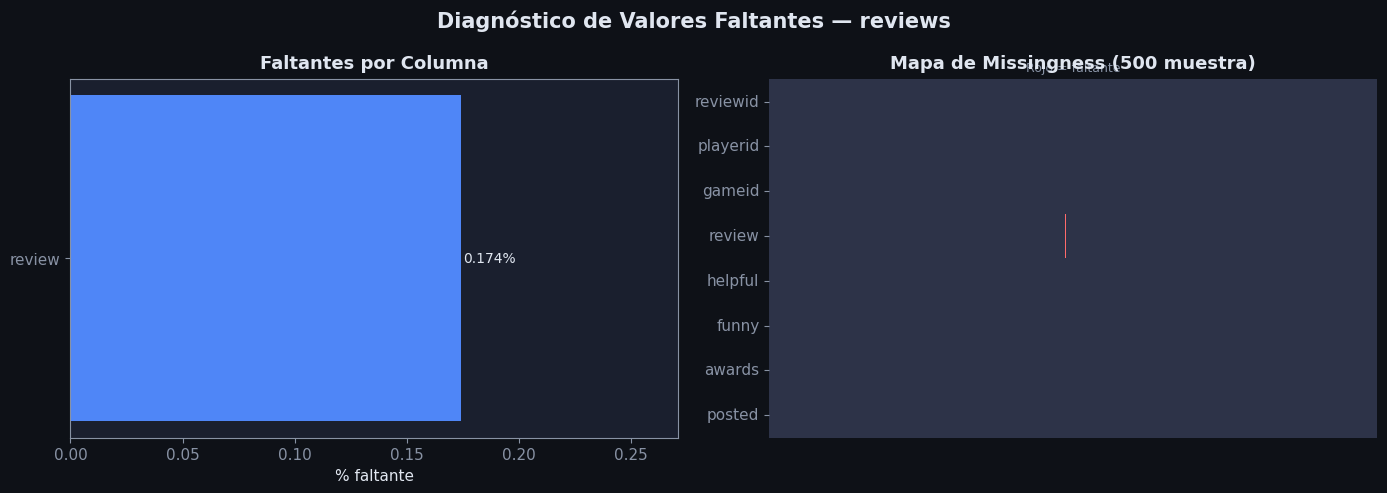

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Diagnóstico de Valores Faltantes — reviews', fontsize=15,
             fontweight='bold', color=TEXT)

ax = axes[0]
cols_m = miss_pct[miss_pct > 0].sort_values()
colors_m = [ACCENT3 if v > 30 else ACCENT4 if v > 5 else ACCENT1 for v in cols_m.values]
bars = ax.barh(cols_m.index, cols_m.values, color=colors_m)
for bar, val in zip(bars, cols_m.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}%', va='center', color=TEXT, fontsize=10)
ax.set_xlim(0, max(cols_m.values) * 1.5 + 0.01)
ax.set_xlabel('% faltante')
title_ax(ax, 'Faltantes por Columna')

ax = axes[1]
sample = df_raw.sample(min(500, len(df_raw)), random_state=42)
miss_m = sample.isnull() | (sample.apply(lambda col: col.astype(str).str.strip() == ''))
sns.heatmap(miss_m.T, ax=ax, cbar=False,
            cmap=['#2d3348', ACCENT3], yticklabels=True, xticklabels=False)
title_ax(ax, 'Mapa de Missingness (500 muestra)', 'Rojo = faltante')

plt.tight_layout()
plt.show()

In [6]:
df = df_raw.copy()

before = len(df)
df['posted'] = pd.to_datetime(df['posted'], errors='coerce')
df = df[df['posted'].notna()].reset_index(drop=True)
print(f"Eliminadas por posted NaT: {before - len(df):,} filas")

mask_review = df['review'].isna() | (df['review'].str.strip() == '')
df['review'] = df['review'].fillna('')
df.loc[df['review'].str.strip() == '', 'review'] = ''
print(f"Reviews vacías conservadas (imputadas con ''): {mask_review.sum():,}")

for col in ['helpful', 'funny', 'awards']:
    n = df[col].isna().sum()
    df[col] = df[col].fillna(0).astype(int)
    print(f"{col} imputado con 0: {n:,} filas")

df['review_len']     = df['review'].str.len()
df['has_text']       = df['review_len'] > 0
df['year']           = df['posted'].dt.year
df['month']          = df['posted'].dt.month
df['is_template']    = df['review'].str.contains(r'---\{|☑|☐', regex=True, na=False)
df['engagement']     = df['helpful'] + df['funny'] + df['awards']

print(f"\nDataset final: {len(df):,} filas")
print(f"Faltantes restantes: {df.isnull().sum().sum()}")
df.head(3)

Eliminadas por posted NaT: 0 filas
Reviews vacías conservadas (imputadas con ''): 2,097
helpful imputado con 0: 0 filas
funny imputado con 0: 0 filas
awards imputado con 0: 0 filas

Dataset final: 1,204,534 filas
Faltantes restantes: 0


,reviewid,playerid,gameid,review,helpful,funny,awards,posted,review_len,has_text,year,month,is_template,engagement
0,639543,76561198796340888,730,Goud gamę i have 3 vac ban acont but i stilll ...,0,0,0,2018-03-22,62,True,2018,3,False,0
1,639544,76561198028706627,393380,---{ Graphics }---☐ You forget what reality is...,0,0,0,2025-01-03,1470,True,2025,1,True,0
2,639545,76561198028706627,10,One of the best FPS games :),0,0,0,2012-05-13,28,True,2012,5,False,0


---
##  Integridad y unicidad

###  Hallazgos
- `reviewid` es una clave primaria válida: 0 duplicados.
- El par `(playerid, gameid)` es único: un jugador tiene como máximo una reseña por juego en esta muestra.
- Los `playerid` siguen el formato estándar de Steam ID64 (enteros de 17 dígitos ~7.65 × 10¹⁶).


In [7]:
print(f"reviewid duplicados              : {df['reviewid'].duplicated().sum():,}")
print(f"(playerid, gameid) duplicados    : {df.duplicated(['playerid','gameid']).sum():,}")
print(f"Jugadores únicos                 : {df['playerid'].nunique():,}")
print(f"Juegos únicos                    : {df['gameid'].nunique():,}")
print(f"Rango de fechas                  : {df['posted'].min().date()} → {df['posted'].max().date()}")
print()
print("Estadísticas de reviewid:")
print(df['reviewid'].describe())

reviewid duplicados              : 0
(playerid, gameid) duplicados    : 0
Jugadores únicos                 : 196,698
Juegos únicos                    : 51,910
Rango de fechas                  : 2010-10-15 → 2025-01-09

Estadísticas de reviewid:
count    1.204534e+06
mean     6.037844e+05
std      3.477332e+05
min      1.497000e+03
25%      3.026392e+05
50%      6.037825e+05
75%      9.049308e+05
max      1.206078e+06
Name: reviewid, dtype: float64


---
##  Actividad por Jugador y por Juego

###  Hallazgos

- La distribución de reseñas por jugador es fuertemente sesgada a la derecha: la mediana es 2 reseñas, mientras que el 1% superior supera las 60 reseñas. El jugador más activo tiene 14,893 reseñas, lo que representa un outlier extremo.
- La distribución de reseñas por juego también muestra una cola larga pronunciada: la mediana es 3 reseñas por juego, pero algunos títulos concentran decenas de miles. El máximo observado en la muestra es 70,529 reseñas.
- La mayoría de los jugadores son esporádicos: el 75% ha escrito 5 reseñas o menos y el 90% 12 o menos, lo cual es consistente con el comportamiento típico en plataformas de consumo donde solo una minoría contribuye activamente con contenido.


In [8]:
reviews_per_player = df.groupby('playerid').size().rename('n_reviews')
reviews_per_game   = df.groupby('gameid').size().rename('n_reviews')

print("Reseñas por jugador:")
print(reviews_per_player.describe(percentiles=[.5, .75, .9, .99]))
print()
print("Reseñas por juego:")
print(reviews_per_game.describe(percentiles=[.5, .75, .9, .99]))

Reseñas por jugador:
count    196698.000000
mean          6.123774
std          50.405434
min           1.000000
50%           2.000000
75%           5.000000
90%          12.000000
99%          60.000000
max       14893.000000
Name: n_reviews, dtype: float64

Reseñas por juego:
count    51910.000000
mean        23.204277
std        365.534661
min          1.000000
50%          3.000000
75%          7.000000
90%         23.000000
99%        337.000000
max      70529.000000
Name: n_reviews, dtype: float64


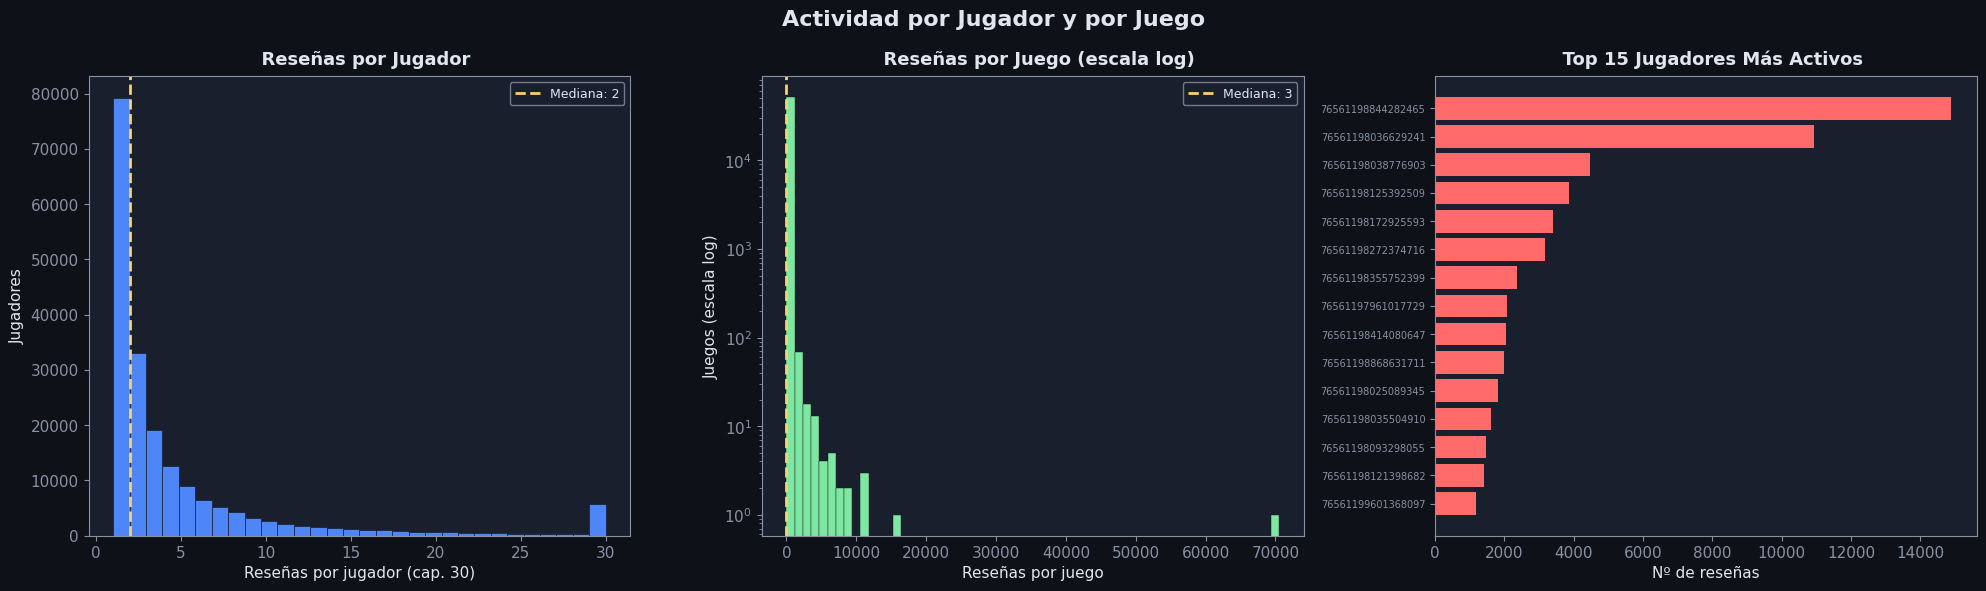

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Actividad por Jugador y por Juego', fontsize=16, fontweight='bold', color=TEXT)

ax = axes[0]
cap_player = reviews_per_player.clip(upper=30)
ax.hist(cap_player, bins=30, color=ACCENT1, edgecolor=DARK_BG, linewidth=0.4)
ax.axvline(reviews_per_player.median(), color=ACCENT4, linewidth=2, linestyle='--',
           label=f"Mediana: {reviews_per_player.median():.0f}")
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Reseñas por jugador (cap. 30)'); ax.set_ylabel('Jugadores')
title_ax(ax, '  Reseñas por Jugador')

ax = axes[1]
ax.hist(reviews_per_game.values, bins=60, color=ACCENT2,
        edgecolor=DARK_BG, linewidth=0.3, log=True)
ax.axvline(reviews_per_game.median(), color=ACCENT4, linewidth=2, linestyle='--',
           label=f"Mediana: {reviews_per_game.median():.0f}")
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Reseñas por juego'); ax.set_ylabel('Juegos (escala log)')
title_ax(ax, '  Reseñas por Juego (escala log)')

ax = axes[2]
top15 = reviews_per_player.sort_values(ascending=False).head(15)
ax.barh(range(len(top15)), top15.values[::-1], color=ACCENT3)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([str(p) for p in top15.index[::-1]], fontsize=7)
ax.set_xlabel('Nº de reseñas')
title_ax(ax, '  Top 15 Jugadores Más Activos')

plt.tight_layout()
plt.show()

---
##  Análisis Temporal

###  Hallazgos

- Las reseñas cubren el período 2010–2025, mostrando un crecimiento sostenido a lo largo del tiempo.
- La actividad aumenta gradualmente desde 2013 en adelante, lo cual es consistente con el lanzamiento del sistema de Steam Reviews en 2013.
- El volumen de reseñas crece fuertemente entre 2016 y 2024, alcanzando su máximo en 2024 (183,087 reseñas).
- El período 2019–2024 concentra la mayor actividad, con más de 100k reseñas por año, lo que refleja el crecimiento de la plataforma y un aumento general en la participación de los usuarios.
- Los años 2010–2012 tienen muy pocas reseñas, posiblemente debido a registros migrados o a actividad previa al sistema formal de reseñas.
- 2025 aparece con muy pocas reseñas (1,552) porque el dataset solo incluye datos hasta inicios del año.


In [10]:
reviews_per_year  = df.groupby('year').size()
reviews_per_month = df.groupby(['year', 'month']).size().reset_index(name='n')

print("Reseñas por año:")
print(reviews_per_year.to_string())

Reseñas por año:
year
2010       733
2011      3203
2012      3883
2013     14050
2014     40207
2015     51170
2016     69458
2017     83406
2018     80324
2019    108268
2020    147404
2021    140577
2022    133043
2023    144169
2024    183087
2025      1552


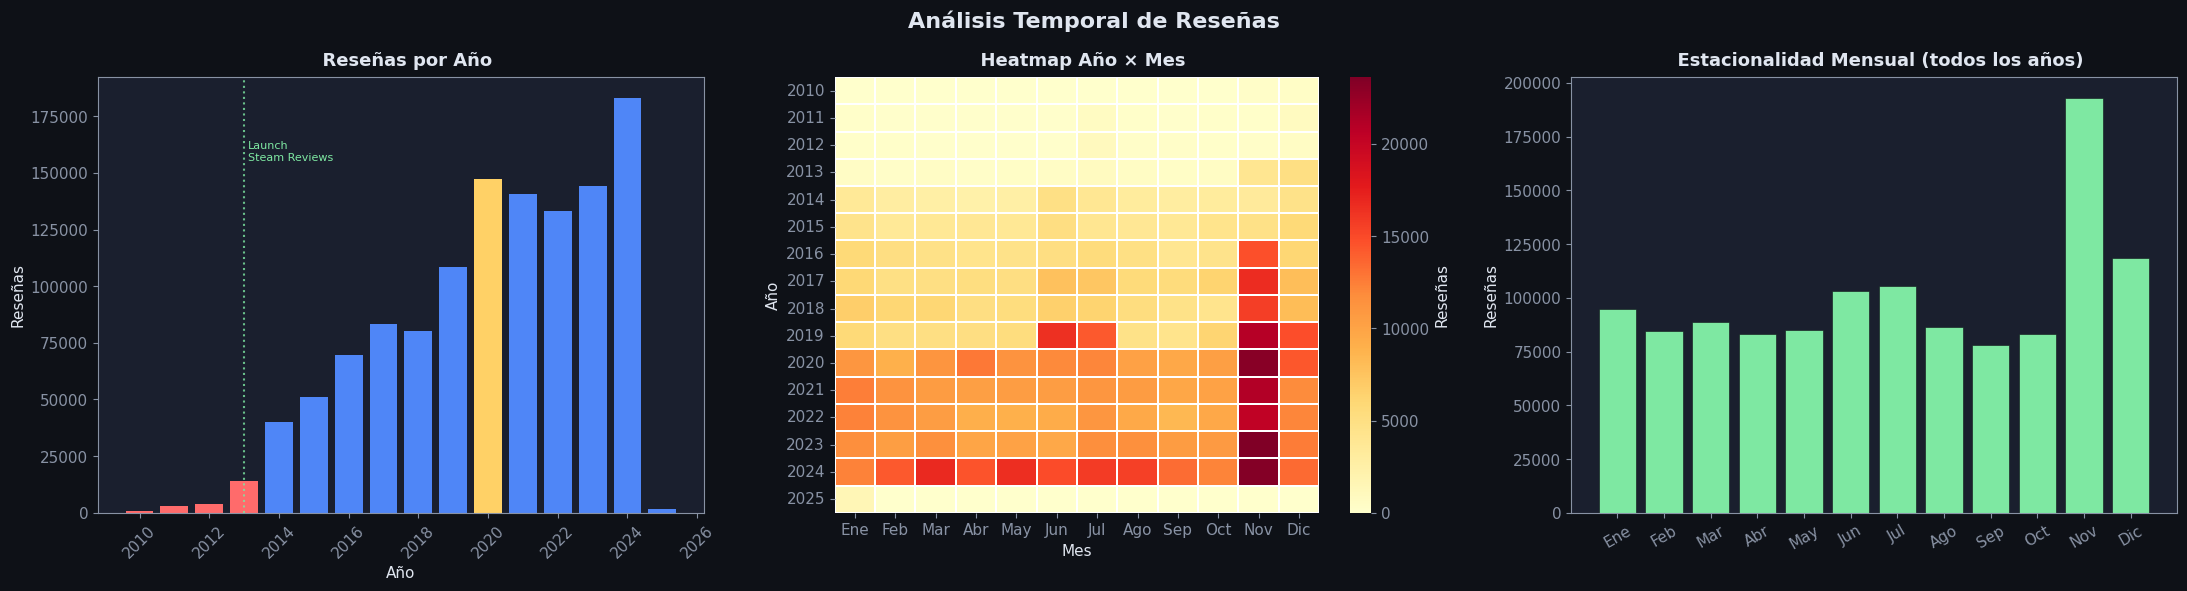

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Análisis Temporal de Reseñas', fontsize=16, fontweight='bold', color=TEXT)

ax = axes[0]
years = reviews_per_year.index.astype(int)
vals  = reviews_per_year.values
colors_y = [ACCENT3 if y <= 2013 else ACCENT4 if y == 2020 else ACCENT1 for y in years]
bars = ax.bar(years, vals, color=colors_y)
ax.set_xlabel('Año'); ax.set_ylabel('Reseñas')
ax.tick_params(axis='x', rotation=45)

ax.axvline(2013, color=ACCENT2, linewidth=1.5, linestyle=':', alpha=0.8)
ax.text(2013.1, max(vals)*0.85, 'Launch\nSteam Reviews', color=ACCENT2, fontsize=8)
title_ax(ax, '  Reseñas por Año')


ax = axes[1]
pivot = reviews_per_month.pivot(index='year', columns='month', values='n').fillna(0)
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Reseñas'},
            xticklabels=['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
ax.set_xlabel('Mes'); ax.set_ylabel('Año')
title_ax(ax, '  Heatmap Año × Mes')


ax = axes[2]
month_agg = df.groupby('month').size()
month_labels = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
ax.bar(range(1, 13), month_agg.reindex(range(1, 13), fill_value=0).values,
       color=ACCENT2, edgecolor=DARK_BG, linewidth=0.4)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, rotation=30)
ax.set_ylabel('Reseñas')
title_ax(ax, '  Estacionalidad Mensual (todos los años)')

plt.tight_layout()
plt.show()

---
##  Análisis de Texto de Reseñas

###  Hallazgos
- La distribución de longitud es **fuertemente sesgada a la derecha**: la mediana es 64 caracteres, mientras que el P99 supera los 4,200. El máximo es 8,000 caracteres (límite de Steam).
- La mayoría de reseñas son muy cortas: el 25% tiene menos de 17 caracteres y hay más de 105k reseñas con menos de 5 caracteres, incluyendo textos como '👍', '.', 'good', o '10/10'.
- Se detectan ~0.15% de reseñas tipo template (formato de casillas ☑/☐), populares en la comunidad pero con **bajo contenido textual original**.
- Existen muchos textos duplicados exactos entre reseñas de distintos jugadores (ej. 'good', '.', 'nice'), lo que sugiere copy-paste, memes comunitarios o posible actividad automatizada.
- El dataset contiene múltiples idiomas (inglés, español, ruso, chino, turco, portugués, entre otros).


In [12]:
print("Longitud de reseñas:")
print(df['review_len'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))
print()
print(f"Reseñas sin texto (len=0)       : {(df['review_len'] == 0).sum():,} ({(df['review_len']==0).mean()*100:.2f}%)")
print(f"Reseñas muy cortas (len < 5)    : {(df['review_len'].between(1,4)).sum():,}")
print(f"Reseñas al límite (len = 8000)  : {(df['review_len'] == 8000).sum():,}")
print(f"Reseñas tipo template           : {df['is_template'].sum():,} ({df['is_template'].mean()*100:.2f}%)")
print()
print("Top 20 textos de reseña más repetidos:")
print(df['review'].value_counts().head(20).to_string())

Longitud de reseñas:
count    1.204534e+06
mean     3.231193e+02
std      7.847585e+02
min      0.000000e+00
25%      1.700000e+01
50%      6.400000e+01
75%      2.500000e+02
90%      8.180000e+02
95%      1.524000e+03
99%      4.222000e+03
max      8.000000e+03
Name: review_len, dtype: float64

Reseñas sin texto (len=0)       : 2,097 (0.17%)
Reseñas muy cortas (len < 5)    : 105,632
Reseñas al límite (len = 8000)  : 26
Reseñas tipo template           : 1,855 (0.15%)

Top 20 textos de reseña más repetidos:
review
☀️                                                                                                                                                                                                                                                                                                                                                  14885
⠀                                                                                                                                      

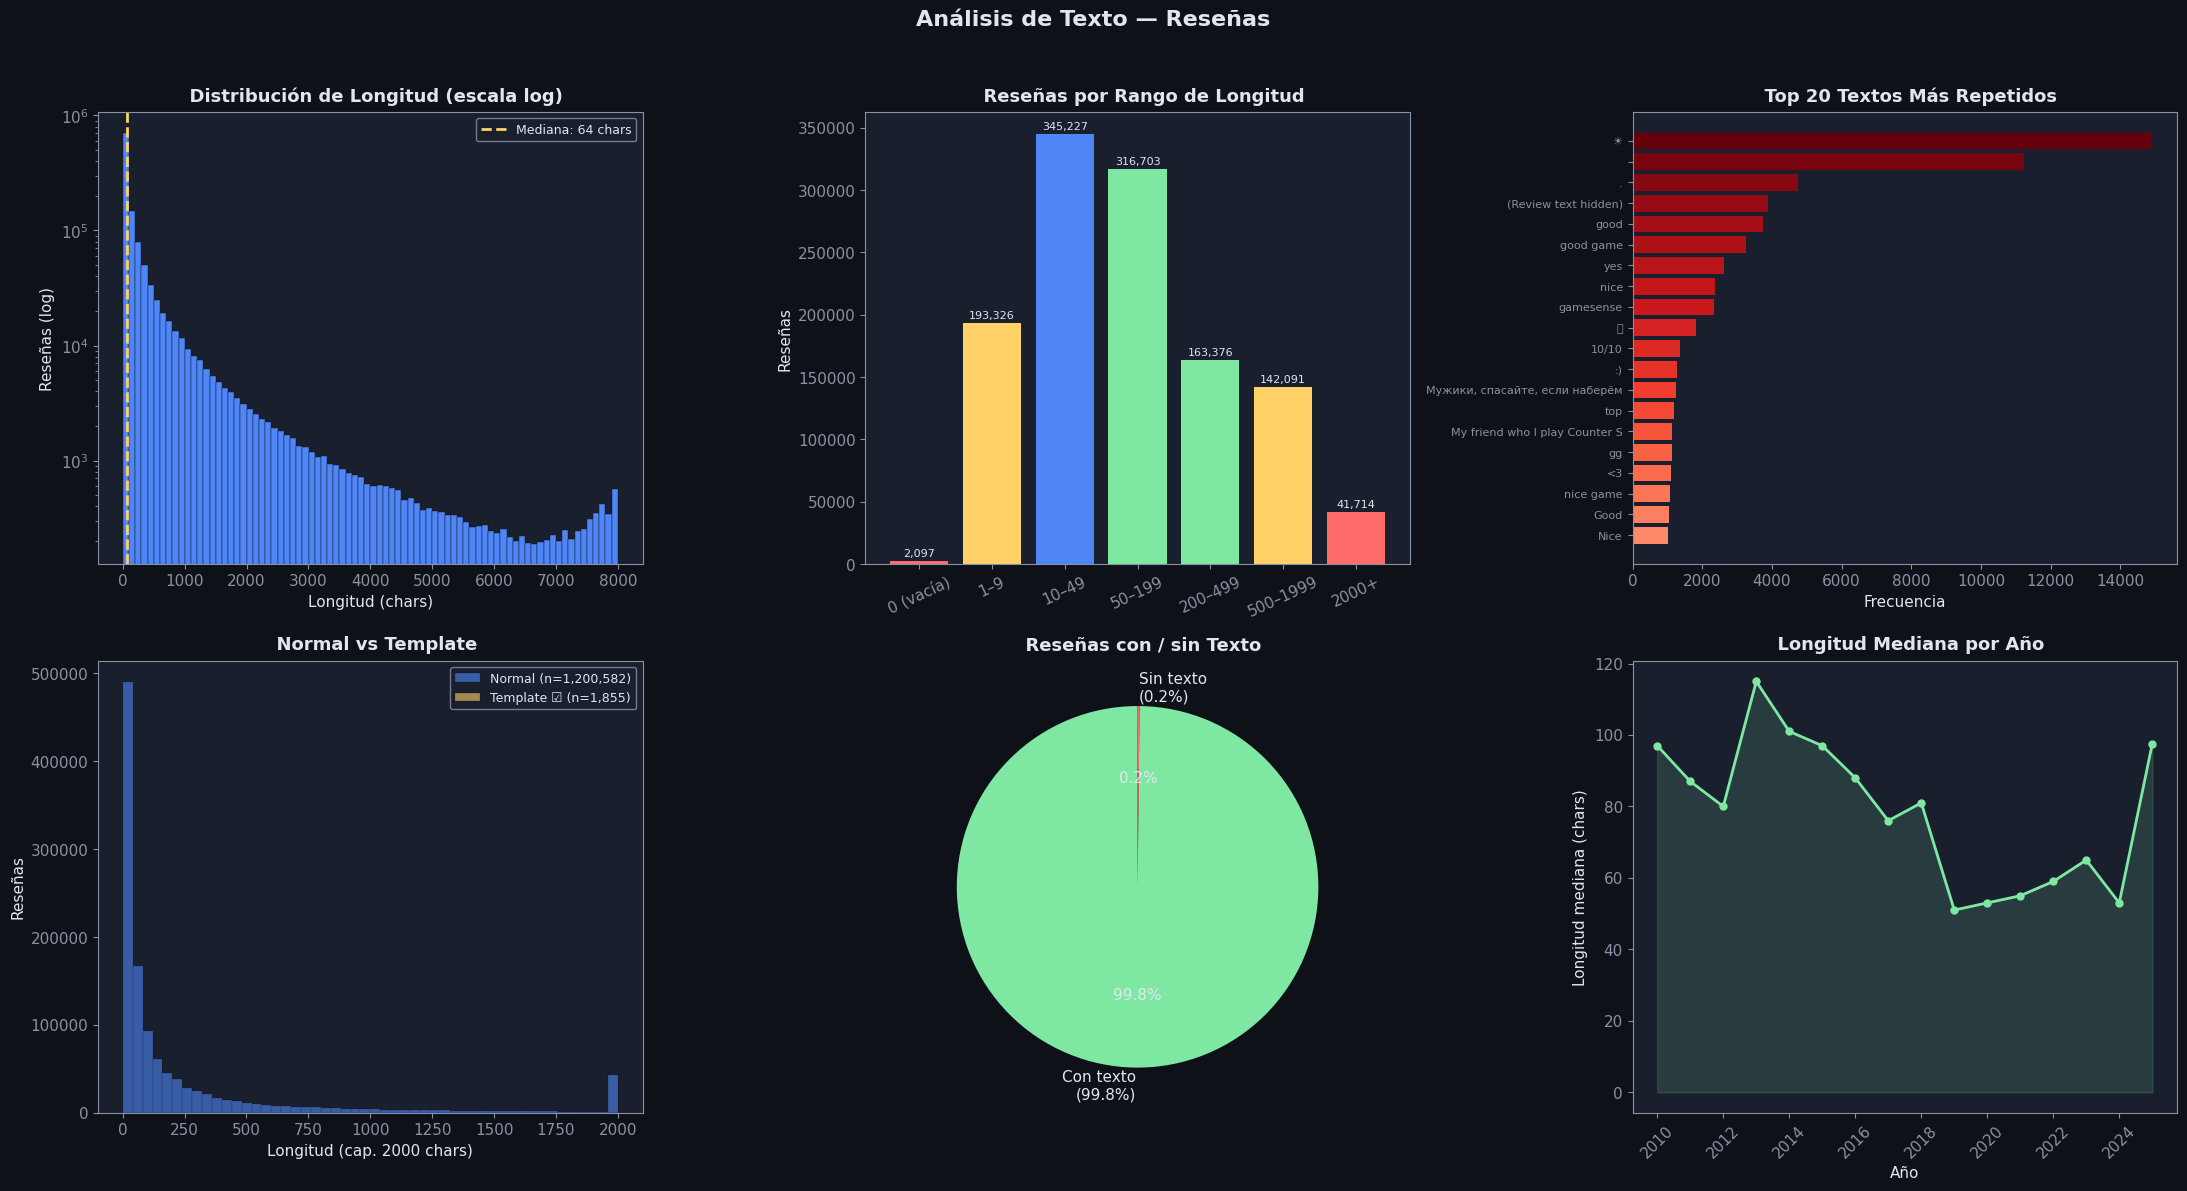

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Análisis de Texto — Reseñas', fontsize=16, fontweight='bold', color=TEXT, y=0.99)

ax = axes[0, 0]
ax.hist(df[df['review_len'] > 0]['review_len'], bins=80,
        color=ACCENT1, edgecolor=DARK_BG, linewidth=0.3, log=True)
ax.axvline(df['review_len'].median(), color=ACCENT4, linewidth=2, linestyle='--',
           label=f"Mediana: {df['review_len'].median():.0f} chars")
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Longitud (chars)'); ax.set_ylabel('Reseñas (log)')
title_ax(ax, '  Distribución de Longitud (escala log)')


ax = axes[0, 1]
len_bins   = [0, 1, 10, 50, 200, 500, 2000, 8001]
len_labels = ['0 (vacía)','1–9','10–49','50–199','200–499','500–1999','2000+']
df['len_bucket'] = pd.cut(df['review_len'], bins=len_bins, labels=len_labels, right=False)
bucket_cnt = df['len_bucket'].value_counts().sort_index()
colors_lb = [ACCENT3, ACCENT4, ACCENT1, ACCENT2, ACCENT2, ACCENT4, ACCENT3]
ax.bar(bucket_cnt.index.astype(str), bucket_cnt.values, color=colors_lb)
for i, v in enumerate(bucket_cnt.values):
    ax.text(i, v + len(df)*0.003, f'{v:,}', ha='center', fontsize=8, color=TEXT)
ax.set_ylabel('Reseñas')
ax.tick_params(axis='x', rotation=25)
title_ax(ax, '  Reseñas por Rango de Longitud')

ax = axes[0, 2]
top_texts = df[df['review_len'] > 0]['review'].value_counts().head(20)
cmap = plt.cm.Reds(np.linspace(0.4, 1.0, len(top_texts)))
ax.barh(range(len(top_texts)), top_texts.values[::-1], color=cmap)
ax.set_yticks(range(len(top_texts)))
ax.set_yticklabels([t[:30] for t in top_texts.index[::-1]], fontsize=8)
ax.set_xlabel('Frecuencia')
title_ax(ax, '  Top 20 Textos Más Repetidos')

ax = axes[1, 0]
for label, mask, color in [
    ('Normal', ~df['is_template'] & (df['review_len'] > 0), ACCENT1),
    ('Template ☑', df['is_template'], ACCENT4),
]:
    data = df[mask]['review_len'].clip(upper=2000)
    ax.hist(data, bins=50, alpha=0.6, color=color, edgecolor=DARK_BG,
            linewidth=0.2, label=f'{label} (n={mask.sum():,})')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Longitud (cap. 2000 chars)'); ax.set_ylabel('Reseñas')
title_ax(ax, '  Normal vs Template')

ax = axes[1, 1]
has_t = df['has_text'].sum()
no_t  = len(df) - has_t
ax.pie([has_t, no_t],
       labels=[f'Con texto\n({has_t/len(df)*100:.1f}%)',
               f'Sin texto\n({no_t/len(df)*100:.1f}%)'],
       colors=[ACCENT2, ACCENT3], startangle=90,
       textprops={'color': TEXT}, autopct='%1.1f%%')
title_ax(ax, '  Reseñas con / sin Texto')

ax = axes[1, 2]
len_by_year = df[df['review_len'] > 0].groupby('year')['review_len'].median()
ax.plot(len_by_year.index, len_by_year.values, color=ACCENT2,
        marker='o', linewidth=2, markersize=5)
ax.fill_between(len_by_year.index, len_by_year.values, alpha=0.15, color=ACCENT2)
ax.set_xlabel('Año'); ax.set_ylabel('Longitud mediana (chars)')
ax.tick_params(axis='x', rotation=45)
title_ax(ax, '  Longitud Mediana por Año')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---
##  Engagement: helpful, funny y awards

###  Hallazgos
- Las tres métricas (`helpful`, `funny`, `awards`) están **fuertemente sesgadas a la derecha**: la mediana es 0 en los tres casos, lo que indica que la mayoría de reseñas no recibe interacción.
- El 34% de las reseñas tiene al menos un voto `helpful`, mientras que 10% recibe votos `funny` y 7% obtiene algún `award` — los premios siguen siendo eventos relativamente raros.
- Los valores máximos muestran outliers extremos: `helpful` llega a 999, `funny` a 988 y `awards` a 8,851, lo que corresponde a reseñas altamente virales o populares dentro de la comunidad.
- El `engagement` total (suma de `helpful`, `funny` y `awards`) está **ligeramente correlacionado con la longitud de la reseña**, aunque con alta varianza: algunas reseñas muy cortas también logran gran visibilidad si contienen humor o memes.


In [14]:
for col in ['helpful', 'funny', 'awards']:
    gt0 = (df[col] > 0).sum()
    print(f"{col:10s}  >0: {gt0:,} ({gt0/len(df)*100:.1f}%)  "
          f"mediana: {df[col].median():.0f}  "
          f"media: {df[col].mean():.2f}  "
          f"max: {df[col].max():.0f}")
print()
print("Top 10 reseñas más útiles (helpful):")
print(df.nlargest(10, 'helpful')[['reviewid','gameid','helpful','funny','awards','review_len']].to_string())

helpful     >0: 410,073 (34.0%)  mediana: 0  media: 5.58  max: 999
funny       >0: 123,046 (10.2%)  mediana: 0  media: 1.25  max: 988
awards      >0: 84,803 (7.0%)  mediana: 0  media: 0.52  max: 8851

Top 10 reseñas más útiles (helpful):
         reviewid   gameid  helpful  funny  awards  review_len
604444      39424  1174180      999    160     277         978
478495    1118077  1272080      997     61     155        1830
109106     749035  1091500      995    284      85          38
1062593    497606  1174180      995     57      53         195
100857     740420   311690      994     75       8          97
391329    1030925   782330      992    253       0          53
942645     377666  2012510      992     41     115        2220
299591     939089  1475810      991      4      15         261
533817    1173405   375950      989    214       0          75
834632     269662   540610      989    253      11        1179


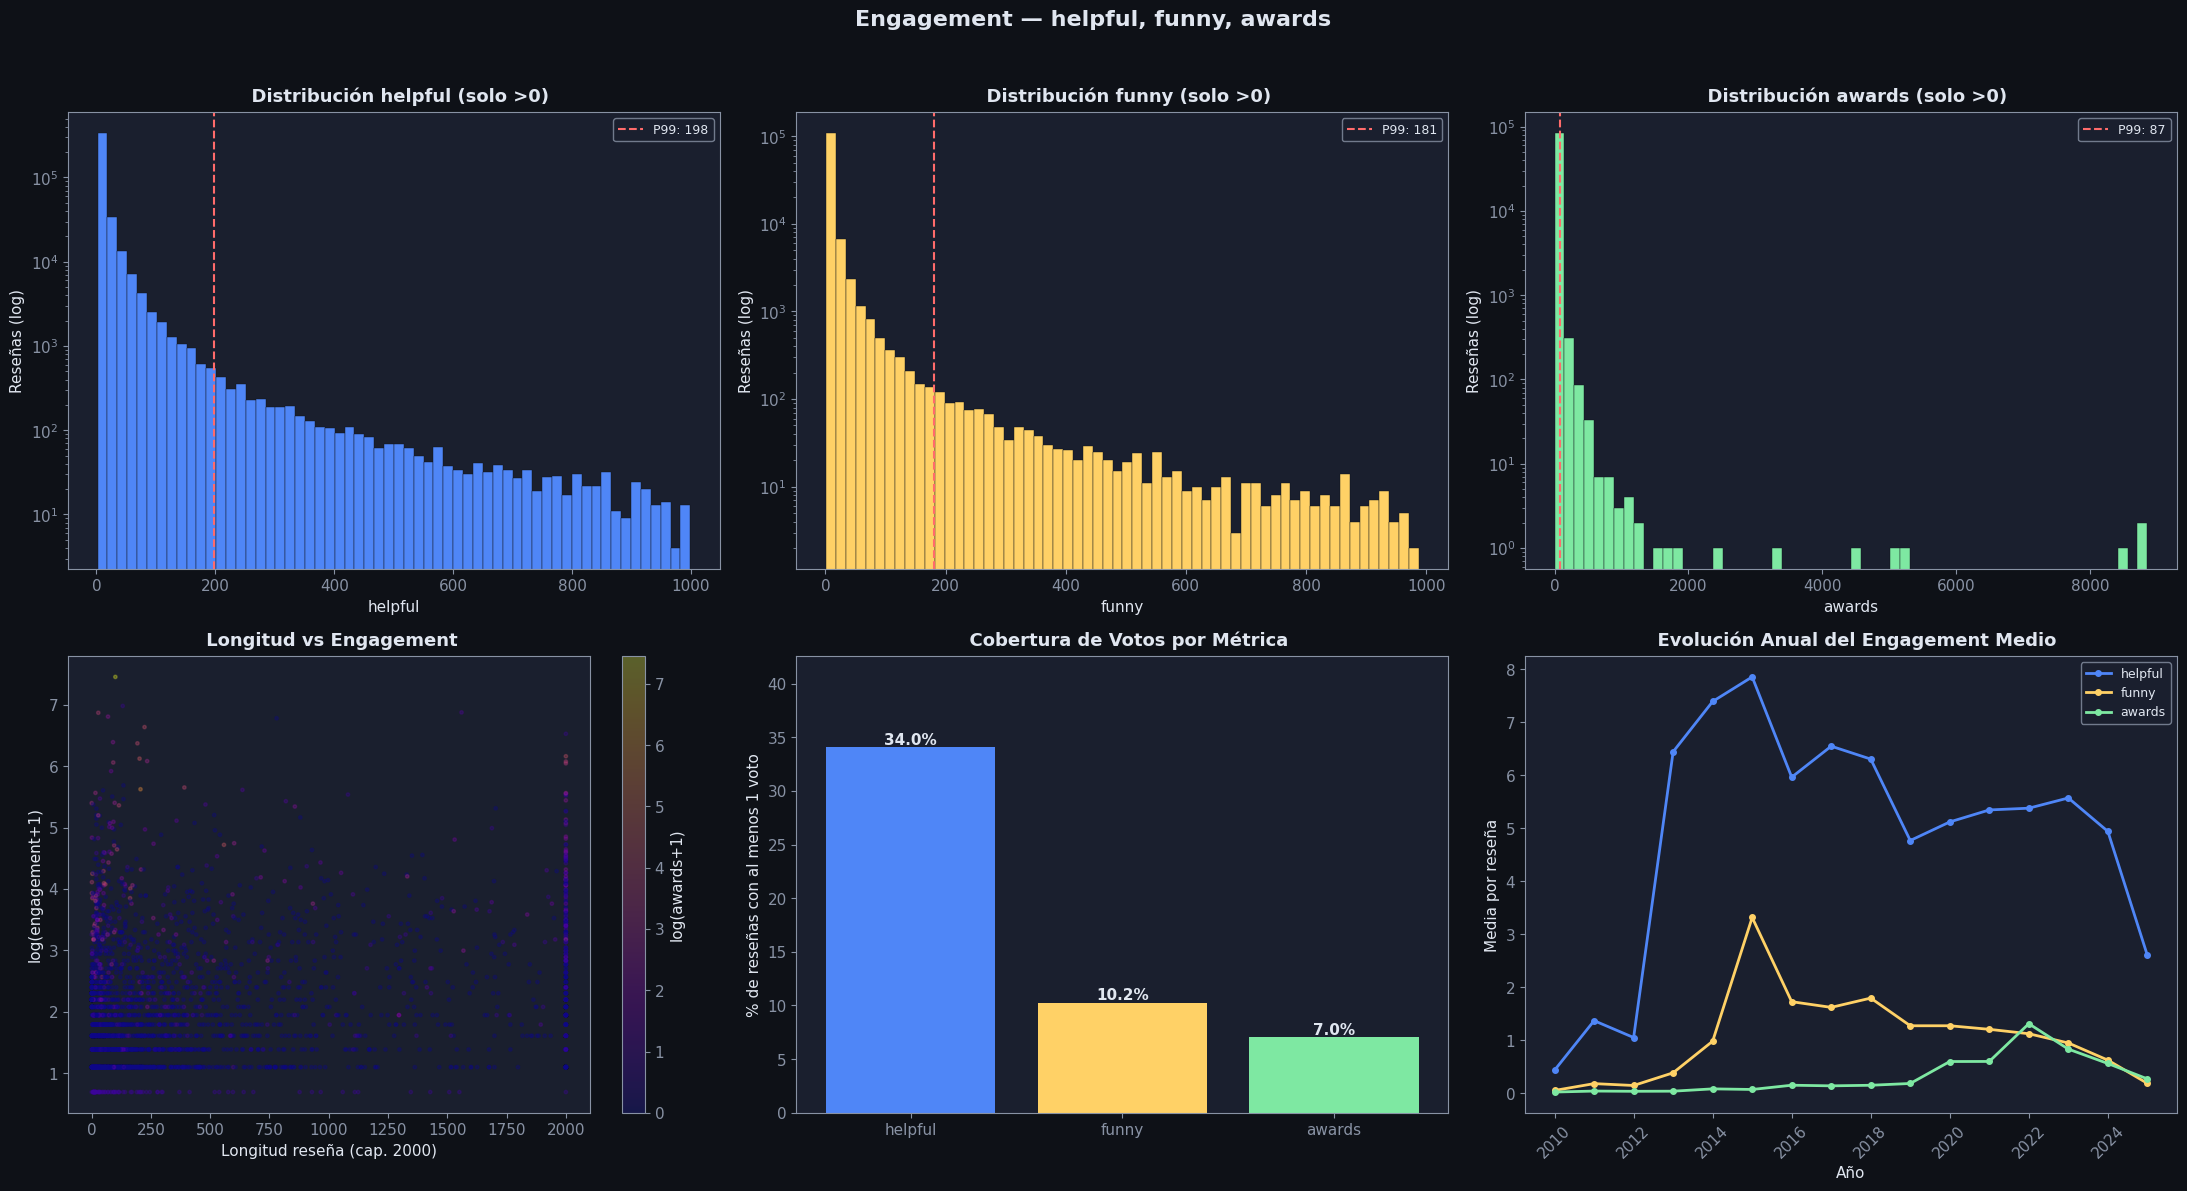

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Engagement — helpful, funny, awards', fontsize=16, fontweight='bold', color=TEXT, y=0.99)

for i, (col, color) in enumerate(zip(['helpful', 'funny', 'awards'],
                                      [ACCENT1, ACCENT4, ACCENT2])):
    ax = axes[0, i]
    data = df[df[col] > 0][col]
    ax.hist(data, bins=60, color=color, edgecolor=DARK_BG, linewidth=0.3, log=True)
    ax.axvline(data.quantile(0.99), color=ACCENT3, linewidth=1.5, linestyle='--',
               label=f'P99: {data.quantile(0.99):.0f}')
    ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
    ax.set_xlabel(col); ax.set_ylabel('Reseñas (log)')
    title_ax(ax, f'  Distribución {col} (solo >0)')

ax = axes[1, 0]
sample = df[df['engagement'] > 0].sample(min(3000, (df['engagement']>0).sum()), random_state=42)
sc = ax.scatter(sample['review_len'].clip(upper=2000), np.log1p(sample['engagement']),
                alpha=0.3, s=6, c=np.log1p(sample['awards']), cmap='plasma')
plt.colorbar(sc, ax=ax, label='log(awards+1)')
ax.set_xlabel('Longitud reseña (cap. 2000)'); ax.set_ylabel('log(engagement+1)')
title_ax(ax, ' Longitud vs Engagement')

ax = axes[1, 1]
met_pct = {col: (df[col] > 0).mean() * 100 for col in ['helpful', 'funny', 'awards']}
ax.bar(list(met_pct.keys()), list(met_pct.values()),
       color=[ACCENT1, ACCENT4, ACCENT2])
for i, (k, v) in enumerate(met_pct.items()):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11,
            color=TEXT, fontweight='bold')
ax.set_ylabel('% de reseñas con al menos 1 voto')
ax.set_ylim(0, max(met_pct.values()) * 1.25)
title_ax(ax, '  Cobertura de Votos por Métrica')

ax = axes[1, 2]
eng_year = df.groupby('year')[['helpful','funny','awards']].mean()
for col, color in zip(['helpful','funny','awards'], [ACCENT1, ACCENT4, ACCENT2]):
    ax.plot(eng_year.index, eng_year[col], marker='o', linewidth=2,
            markersize=4, color=color, label=col)
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Año'); ax.set_ylabel('Media por reseña')
ax.tick_params(axis='x', rotation=45)
title_ax(ax, '  Evolución Anual del Engagement Medio')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---
##  Outliers

###  Contexto
Se identifican outliers en tres dimensiones: jugadores hiper-activos, reseñas con engagement viral y reseñas con longitud máxima permitida por Steam (8,000 caracteres).

###  Hallazgos
- 10% de los jugadores superan el umbral IQR (>11 reseñas), pero generan 59.5% de todas las reseñas, lo que muestra una fuerte concentración de actividad.
- Los outliers de engagement son raros: ~1% de reseñas superan el P99 en `helpful`, `funny` o `awards`.
- Solo 26 reseñas alcanzan el límite máximo de 8,000 caracteres (0.002%), por lo que este tipo de outlier es extremadamente raro.



In [16]:
rpp = df.groupby('playerid').size().rename('n_reviews')
Q1_p, Q3_p = rpp.quantile(0.25), rpp.quantile(0.75)
IQR_p = Q3_p - Q1_p
iqr_upper_player = Q3_p + 1.5 * IQR_p

hyperactive = rpp[rpp > iqr_upper_player]

print(f"IQR upper (jugadores)           : {iqr_upper_player:.1f} reseñas")
print(f"Jugadores hiper-activos (>IQR)  : {len(hyperactive):,} ({len(hyperactive)/len(rpp)*100:.1f}% de jugadores)")
print(f"Reseñas de jugadores hiper-act. : {hyperactive.sum():,} ({hyperactive.sum()/len(df)*100:.1f}% de reseñas)")
print()

for col in ['helpful', 'funny', 'awards']:
    p99 = df[col].quantile(0.99)
    n_out = (df[col] > p99).sum()
    print(f"{col:10s} P99={p99:.0f}  outliers (>P99): {n_out:,} ({n_out/len(df)*100:.2f}%)")
print()

at_limit = (df['review_len'] == 8000).sum()
print(f"Reseñas en el límite de 8000 chars: {at_limit:,} ({at_limit/len(df)*100:.3f}%)")

df['is_hyperactive_player'] = df['playerid'].isin(hyperactive.index)
df['is_viral']  = (df['helpful'] > df['helpful'].quantile(0.99)) | \
                  (df['funny']   > df['funny'].quantile(0.99))   | \
                  (df['awards']  > df['awards'].quantile(0.99))
df['is_max_len'] = df['review_len'] == 8000

print()
print("Flags de outlier agregados al dataframe:")
print(f"  is_hyperactive_player : {df['is_hyperactive_player'].sum():,}")
print(f"  is_viral              : {df['is_viral'].sum():,}")
print(f"  is_max_len            : {df['is_max_len'].sum():,}")

IQR upper (jugadores)           : 11.0 reseñas
Jugadores hiper-activos (>IQR)  : 19,722 (10.0% de jugadores)
Reseñas de jugadores hiper-act. : 717,247 (59.5% de reseñas)

helpful    P99=91  outliers (>P99): 11,868 (0.99%)
funny      P99=20  outliers (>P99): 11,611 (0.96%)
awards     P99=9  outliers (>P99): 11,248 (0.93%)

Reseñas en el límite de 8000 chars: 26 (0.002%)

Flags de outlier agregados al dataframe:
  is_hyperactive_player : 717,247
  is_viral              : 26,014
  is_max_len            : 26


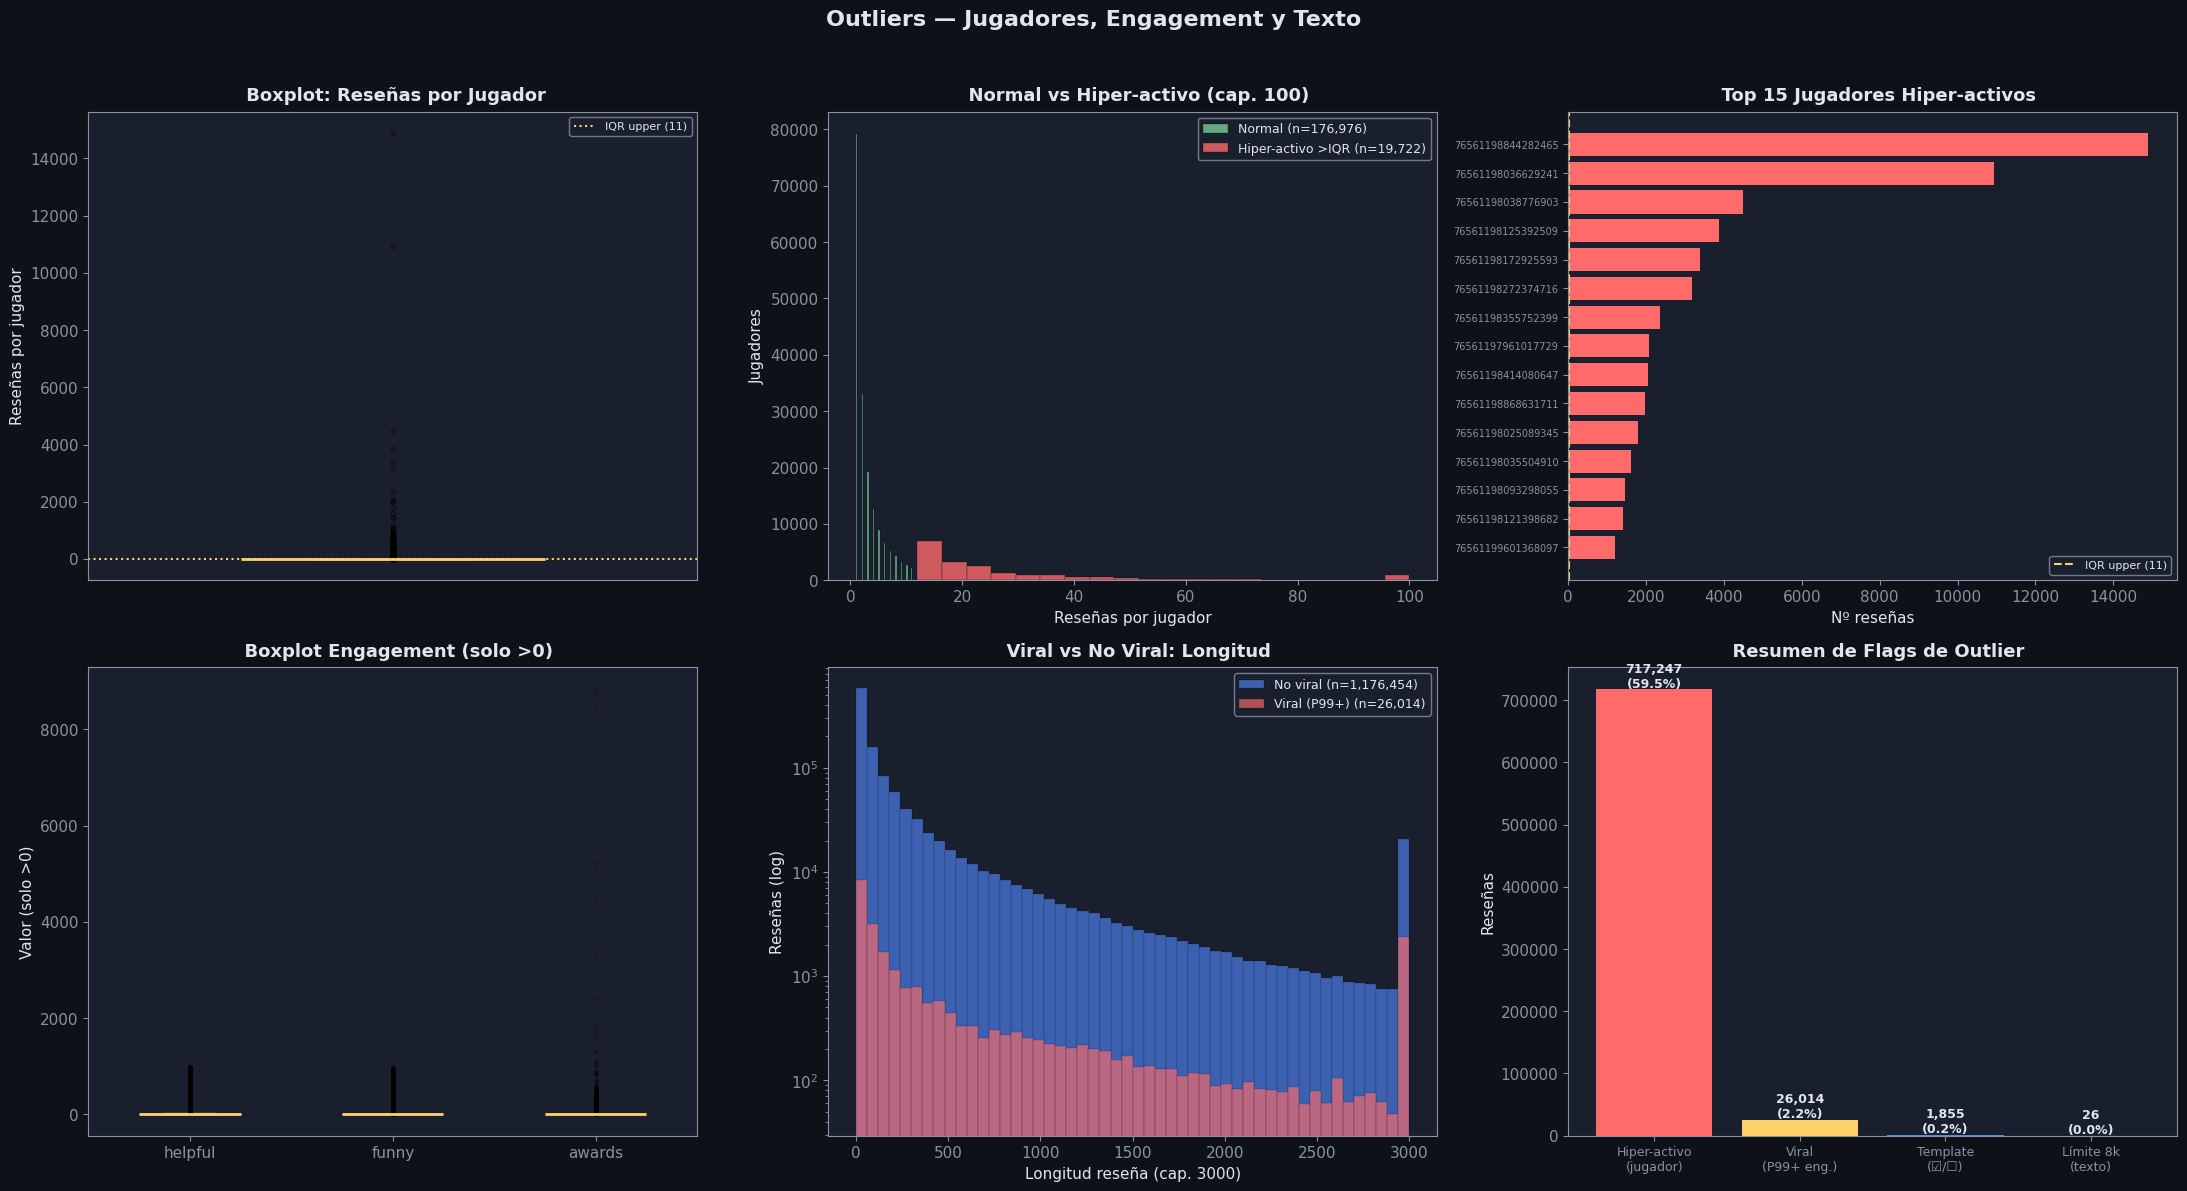

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Outliers — Jugadores, Engagement y Texto', fontsize=16, fontweight='bold', color=TEXT, y=0.99)

from matplotlib.patches import Patch

ax = axes[0, 0]
bp = ax.boxplot(rpp.values, vert=True, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor=ACCENT1, color=MUTED),
                medianprops=dict(color=ACCENT4, linewidth=2),
                whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                flierprops=dict(marker='o', color=ACCENT3, alpha=0.4, markersize=3))
ax.axhline(iqr_upper_player, color=ACCENT4, linestyle=':', linewidth=1.5,
           label=f'IQR upper ({iqr_upper_player:.0f})')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_ylabel('Reseñas por jugador'); ax.set_xticks([])
title_ax(ax, ' Boxplot: Reseñas por Jugador')

ax = axes[0, 1]
normal_p  = rpp[rpp <= iqr_upper_player]
hyper_p   = rpp[rpp > iqr_upper_player]
ax.hist(normal_p.values, bins=40, color=ACCENT2, alpha=0.7,
        edgecolor=DARK_BG, linewidth=0.3, label=f'Normal (n={len(normal_p):,})')
ax.hist(hyper_p.values.clip(max=100), bins=20, color=ACCENT3, alpha=0.8,
        edgecolor=DARK_BG, linewidth=0.3, label=f'Hiper-activo >IQR (n={len(hyper_p):,})')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Reseñas por jugador'); ax.set_ylabel('Jugadores')
title_ax(ax, '  Normal vs Hiper-activo (cap. 100)')

ax = axes[0, 2]
top15_h = hyperactive.sort_values(ascending=False).head(15)
ax.barh(range(len(top15_h)), top15_h.values[::-1], color=ACCENT3)
ax.set_yticks(range(len(top15_h)))
ax.set_yticklabels([str(p) for p in top15_h.index[::-1]], fontsize=7)
ax.axvline(iqr_upper_player, color=ACCENT4, linewidth=1.5, linestyle='--',
           label=f'IQR upper ({iqr_upper_player:.0f})')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Nº reseñas')
title_ax(ax, '  Top 15 Jugadores Hiper-activos')

ax = axes[1, 0]
data_eng = [df[df[c] > 0][c].values for c in ['helpful', 'funny', 'awards']]
bp2 = ax.boxplot(data_eng, vert=True, patch_artist=True, widths=0.5,
                 labels=['helpful', 'funny', 'awards'],
                 boxprops=dict(color=MUTED),
                 medianprops=dict(color=ACCENT4, linewidth=2),
                 whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                 flierprops=dict(marker='o', alpha=0.2, markersize=2))
for patch, color in zip(bp2['boxes'], [ACCENT1, ACCENT4, ACCENT2]):
    patch.set_facecolor(color)
ax.set_ylabel('Valor (solo >0)')
title_ax(ax, '  Boxplot Engagement (solo >0)')

ax = axes[1, 1]
for label, mask, color in [
    ('No viral', ~df['is_viral'] & (df['review_len'] > 0), ACCENT1),
    ('Viral (P99+)', df['is_viral'], ACCENT3),
]:
    data = df[mask]['review_len'].clip(upper=3000)
    ax.hist(data, bins=50, alpha=0.65, color=color, edgecolor=DARK_BG,
            linewidth=0.2, label=f'{label} (n={mask.sum():,})', log=True)
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Longitud reseña (cap. 3000)'); ax.set_ylabel('Reseñas (log)')
title_ax(ax, '  Viral vs No Viral: Longitud')

ax = axes[1, 2]
flag_cols   = ['is_hyperactive_player', 'is_viral', 'is_template', 'is_max_len']
flag_labels = ['Hiper-activo\n(jugador)', 'Viral\n(P99+ eng.)', 'Template\n(☑/☐)', 'Límite 8k\n(texto)']
flag_vals   = [df[c].sum() for c in flag_cols]
flag_colors = [ACCENT3, ACCENT4, ACCENT1, '#ff00ff']
ax.bar(flag_labels, flag_vals, color=flag_colors)
for i, v in enumerate(flag_vals):
    ax.text(i, v + len(df)*0.003, f'{v:,}\n({v/len(df)*100:.1f}%)',
            ha='center', fontsize=9, color=TEXT, fontweight='bold')
ax.set_ylabel('Reseñas')
ax.tick_params(axis='x', labelsize=9)
title_ax(ax, '  Resumen de Flags de Outlier')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---
##  Dataset limpio final

In [18]:
print("═" * 60)
print("  RESUMEN DEL DATASET LIMPIO — reviews")
print("═" * 60)
print(f"  Filas originales             : {df_raw.shape[0]:>10,}")
print(f"  Eliminadas (posted NaT)      : {df_raw.shape[0] - len(df):>10,}")
print(f"  Filas finales                : {len(df):>10,}")
print(f"  Jugadores únicos             : {df['playerid'].nunique():>10,}")
print(f"  Juegos únicos                : {df['gameid'].nunique():>10,}")
print(f"  Reseñas sin texto            : {(~df['has_text']).sum():>10,}  ({(~df['has_text']).mean()*100:.2f}%)")
print(f"  Reseñas tipo template        : {df['is_template'].sum():>10,}  ({df['is_template'].mean()*100:.2f}%)")
print(f"  Jugadores hiper-activos      : {df['is_hyperactive_player'].sum():>10,}  ({df['is_hyperactive_player'].mean()*100:.1f}%)")
print(f"  Reseñas virales (P99+)       : {df['is_viral'].sum():>10,}  ({df['is_viral'].mean()*100:.2f}%)")
print(f"  Faltantes restantes          : {df.isnull().sum().sum():>10,}")
print("═" * 60)
df.head(3)

════════════════════════════════════════════════════════════
  RESUMEN DEL DATASET LIMPIO — reviews
════════════════════════════════════════════════════════════
  Filas originales             :  1,204,534
  Eliminadas (posted NaT)      :          0
  Filas finales                :  1,204,534
  Jugadores únicos             :    196,698
  Juegos únicos                :     51,910
  Reseñas sin texto            :      2,097  (0.17%)
  Reseñas tipo template        :      1,855  (0.15%)
  Jugadores hiper-activos      :    717,247  (59.5%)
  Reseñas virales (P99+)       :     26,014  (2.16%)
  Faltantes restantes          :          0
════════════════════════════════════════════════════════════


,reviewid,playerid,gameid,review,helpful,funny,awards,posted,review_len,has_text,year,month,is_template,engagement,len_bucket,is_hyperactive_player,is_viral,is_max_len
0,639543,76561198796340888,730,Goud gamę i have 3 vac ban acont but i stilll ...,0,0,0,2018-03-22,62,True,2018,3,False,0,50–199,False,False,False
1,639544,76561198028706627,393380,---{ Graphics }---☐ You forget what reality is...,0,0,0,2025-01-03,1470,True,2025,1,True,0,500–1999,False,False,False
2,639545,76561198028706627,10,One of the best FPS games :),0,0,0,2012-05-13,28,True,2012,5,False,0,10–49,False,False,False


---
## Exportar dataset limpio

> Exporta el dataframe limpio con todas las columnas calculadas en este EDA. El notebook `eda_feature_engineering` carga este CSV directamente — no recalcula nada.

**Archivos generados:**
- `reviews_per_game.csv` — una fila por juego: `gameid`, `n_reviews`, `n_reviews_log`, `avg_helpful`, `avg_funny`, `avg_awards`, `avg_engagement`, `pct_with_text`, `avg_review_len`
- `reviews_per_player.csv` — una fila por jugador: `playerid`, `n_reviews`, `is_hyperactive_player`


In [19]:
import numpy as np

reviews_per_game = df.groupby('gameid').agg(
    n_reviews      =('reviewid',    'count'),
    avg_helpful    =('helpful',     'mean'),
    avg_funny      =('funny',       'mean'),
    avg_awards     =('awards',      'mean'),
    avg_engagement =('engagement',  'mean'),
    pct_with_text  =('has_text',    'mean'),
    avg_review_len =('review_len',  'mean'),
).reset_index()
reviews_per_game['n_reviews_log'] = np.log1p(reviews_per_game['n_reviews'])
reviews_per_game.to_csv('Datos/reviews_per_game.csv', index=False)

reviews_per_player = df.groupby('playerid').agg(
    n_reviews              =('reviewid',               'count'),
    is_hyperactive_player  =('is_hyperactive_player',  'first'),
).reset_index()
reviews_per_player.to_csv('Datos/reviews_per_player.csv', index=False)

print(f'reviews_per_game.csv   : {len(reviews_per_game):,} juegos')
print(f'reviews_per_player.csv : {len(reviews_per_player):,} jugadores')
reviews_per_game.head(3)


reviews_per_game.csv   : 51,910 juegos
reviews_per_player.csv : 196,698 jugadores


,gameid,n_reviews,avg_helpful,avg_funny,avg_awards,avg_engagement,pct_with_text,avg_review_len,n_reviews_log
0,10,3489,1.962453,0.431356,0.326455,2.720264,0.996847,80.823158,8.157657
1,20,174,13.528736,2.155172,0.419540,16.103448,1.000000,155.114943,5.164786
2,30,126,3.777778,0.492063,0.126984,4.396825,1.000000,187.190476,4.844187


---
## 10. Conclusiones

### Próximos pasos
- **Features para clasificación:** usar `n_reviews` por juego, `positive_ratio` (helpful / total), y `avg_engagement` como señales de reputación del juego en el modelo de clasificación.
- Cruzar con `games` para enriquecer con género: ¿qué géneros reciben reseñas más largas o con más engagement?
- Cruzar con `history` para ver si los jugadores con más logros desbloqueados (`n_logros_par`) escriben reseñas más largas o con mayor engagement — validación indirecta de que reviews correlaciona con engagement real.
- Investigar los jugadores con >100 reseñas: ¿son bots, curadores o reviewers legítimos muy activos?